# L1.4 — The motion command

**Level 1 · Core · 40 minutes**

**Goal.** You can write the command that all the modules speak.

**Check at the end.** You can say why `None` is different from 0, and which channels each airframe
reads.

> Level 1 uses no simulation loop. You call each module directly.
>
> The text in this course obeys ASD-STE100 Simplified Technical English.

## 1. One currency between the modules

`MotionCommand` is the only thing that guidance, separation and kinematics pass between them. It is
a **setpoint**, not a state to jump to. Each field targets one channel of motion. A `Kinematics`
model reads the fields its vehicle understands and ignores the rest.

The shape comes from a PX4 offboard setpoint. Every field defaults to `None`, which means
"not commanded".

In [1]:
import dataclasses

from opencdarr import M600, SMALL_FIXEDWING, MotionCommand, create_aircraft

print(f"{'field':<28}{'default'}")
for f in dataclasses.fields(MotionCommand):
    print(f"{f.name:<28}{getattr(MotionCommand(), f.name)}")

field                       default
target_velocity             None
target_body_velocity        None
target_position             None
target_leg_start            None
target_loiter_radius        None
target_yaw                  None
target_yawspeed             None
target_course               None
target_airspeed_direction   None
target_airspeed             None
target_lateral_accel        None
target_altitude             None
target_vertical_speed       None


## 2. The channels, and who reads them

| Channel | Unit | `Multirotor` | `FixedWing` | What it means |
| --- | --- | --- | --- | --- |
| `target_velocity` | m/s | **reads** | ignores | The ground velocity `(v_east, v_north)`. The resolvers' output. |
| `target_body_velocity` | m/s | **reads** | — | `(v_forward, v_right)` in the body frame. It takes precedence over `target_velocity`. |
| `target_position` | deg | **reads** | **reads** | The waypoint `(lat, lon)`. |
| `target_leg_start` | deg | ignores | **reads** | The previous waypoint. With `target_position` it makes the leg line. |
| `target_loiter_radius` | m | ignores | **reads** | The orbit radius at the final waypoint. A multirotor hovers instead. |
| `target_yaw` | deg | **reads** | — | The nose heading, apart from the travel direction. |
| `target_yawspeed` | deg/s | **reads** | — | The yaw rate, used when `target_yaw` is not set. |
| `target_course` | deg | — | **reads** | The ground-track course χ. |
| `target_airspeed_direction` | deg | — | **reads** | The heading ψ of the airspeed vector. It **overrides** `target_course`. |
| `target_airspeed` | m/s | — | **reads** | The equivalent airspeed. Not a ground speed. |
| `target_lateral_accel` | m/s² | — | **reads** | A feedforward on the bank. Optional. |
| `target_altitude`, `target_vertical_speed` | m, m/s | — | — | Defined, and ignored. This pass is 2D. |

A dash means the vehicle has no such degree of freedom. A multirotor has no bank, and a fixed-wing
has no independent yaw.

## 3. Build a velocity command

Two constructors, and four derived reads over the same field.

```python
MotionCommand.from_track_speed(hdg_deg, speed)      # aviation heading + speed
MotionCommand.from_velocity(v_east, v_north)        # components
cmd.v_east, cmd.v_north, cmd.gs, cmd.trk            # read it back, either way
```

`from_track_speed` uses a sine and a cosine, so it leaves a rounding term of about 1e-16 in the
component it should set to zero. Compare the derived reads, not the raw tuple.

In [2]:
a = MotionCommand.from_track_speed(90.0, 10.0)
b = MotionCommand.from_velocity(10.0, 0.0)

print(f"{'':<22}{'v_east':>9}{'v_north':>10}{'gs':>8}{'trk':>8}")
for name, cmd in (("from_track_speed", a), ("from_velocity", b)):
    print(f"{name:<22}{cmd.v_east:>9.3f}{cmd.v_north:>10.3f}{cmd.gs:>8.3f}{cmd.trk:>8.1f}")

print(f"\nraw target_velocity, from_track_speed  {a.target_velocity}")
print(f"raw target_velocity, from_velocity     {b.target_velocity}")
print(f"exactly equal: {a == b}    <- the trig leaves a rounding term, so compare the reads")
print(f"\nonly target_velocity is set: "
      f"{ {f.name for f in dataclasses.fields(a) if getattr(a, f.name) is not None} }")

                         v_east   v_north      gs     trk
from_track_speed         10.000     0.000  10.000    90.0
from_velocity            10.000     0.000  10.000    90.0

raw target_velocity, from_track_speed  (10.0, 6.123233995736766e-16)
raw target_velocity, from_velocity     (10.0, 0.0)
exactly equal: False    <- the trig leaves a rounding term, so compare the reads

only target_velocity is set: {'target_velocity'}


## 4. `None` is not zero

`None` means "this channel is not commanded". `0.0` means "command this channel to zero". The two
give different flight.

- `target_yaw=None` — hold the current nose heading.
- `target_yaw=0.0` — turn the nose to the north.

A model that needs a channel and does not find it **fails immediately**. It does not guess. An
under-specified command for that vehicle is an error in your code, and the message names the
channel that is missing.

In [3]:
from opencdarr.kinematics import FixedWing, Multirotor

copter = create_aircraft(M600, id="COPTER", lat=52.0, lon=4.0, trk=0.0, gs=10.0)
plane = create_aircraft(SMALL_FIXEDWING, id="PLANE", lat=52.0, lon=4.0, trk=0.0, gs=17.0)

trials = [
    ("Multirotor, empty command", Multirotor(), copter, M600, MotionCommand()),
    ("Multirotor, fixed-wing channels only", Multirotor(), copter, M600,
     MotionCommand(target_course=90.0, target_airspeed=10.0)),
    ("FixedWing, empty command", FixedWing(), plane, SMALL_FIXEDWING, MotionCommand()),
    ("FixedWing, a raw velocity", FixedWing(), plane, SMALL_FIXEDWING,
     MotionCommand.from_track_speed(90.0, 17.0)),
]

for label, model, state, perf, cmd in trials:
    try:
        model.step(state, cmd, perf, dt=1.0)
        print(f"{label:<38} flown")
    except ValueError as exc:
        print(f"{label:<38} refused")
        print(f"      {str(exc).split(':')[0]}")

Multirotor, empty command              refused
      MotionCommand has no target_velocity
Multirotor, fixed-wing channels only   refused
      MotionCommand has no target_velocity
FixedWing, empty command               refused
      MotionCommand has no fixed-wing channel (target_position / target_course / target_airspeed_direction / target_airspeed)
FixedWing, a raw velocity              refused
      MotionCommand has no fixed-wing channel (target_position / target_course / target_airspeed_direction / target_airspeed)


## 5. A fixed-wing cannot fly a raw velocity

The last row of section 4 is the one to remember. Every resolver returns `target_velocity`, because
that is the natural output of an avoidance calculation. A fixed-wing cannot obey it: it has no
sideways degree of freedom, and its speed is an airspeed with a stall floor.

`project_to_fixedwing(command, perf)` converts the one into the other. It turns a ground-velocity
setpoint into a course and an airspeed, inside the envelope.

In a run you never call it. `run_fleet` puts the adapter in front of any fixed-wing for you. Call it
here to see what it does.

In [4]:
from opencdarr.separation import project_to_fixedwing

raw = MotionCommand.from_track_speed(90.0, 17.0)
projected = project_to_fixedwing(raw, SMALL_FIXEDWING)

def channels(cmd: MotionCommand) -> dict[str, object]:
    return {f.name: getattr(cmd, f.name) for f in dataclasses.fields(cmd)
            if getattr(cmd, f.name) is not None}

print(f"the resolver said   {channels(raw)}")
print(f"the adapter said    {channels(projected)}")

after = FixedWing().step(plane, projected, SMALL_FIXEDWING, dt=1.0)
print(f"\nafter 1 s:  trk {after.trk:.2f} deg   bank {after.bank:.1f} deg   gs {after.gs:.2f} m/s")

# a speed below the stall floor is raised into the envelope, not obeyed
slow = project_to_fixedwing(MotionCommand.from_track_speed(90.0, 4.0), SMALL_FIXEDWING)
print(f"a 4 m/s request becomes  {channels(slow)}   (v_min is {SMALL_FIXEDWING.v_min:.0f} m/s)")

the resolver said   {'target_velocity': (17.0, 1.0409497792752501e-15)}
the adapter said    {'target_course': 90.0, 'target_airspeed': 17.0}

after 1 s:  trk 31.92 deg   bank 44.0 deg   gs 17.00 m/s
a 4 m/s request becomes  {'target_course': 90.0, 'target_airspeed': 12.0}   (v_min is 12 m/s)


## 6. Precedence between two channels

Two pairs of channels overlap, and the rule is fixed:

- `target_body_velocity` wins over `target_velocity` on a multirotor.
- `target_airspeed_direction` wins over `target_course` on a fixed-wing.

The body-frame channel resolves through the current `yaw`, so "forward" is a fixed world direction
only when the yaw says so.

In [5]:
# the same aircraft, pointing east, given both channels at once
pointing_east = dataclasses.replace(
    create_aircraft(M600, id="COPTER", lat=52.0, lon=4.0, trk=0.0, gs=0.0), yaw=90.0)

both = MotionCommand(target_body_velocity=(5.0, 0.0),      # 5 m/s forward, along the nose
                     target_velocity=(0.0, 5.0))           # 5 m/s north

out = Multirotor().step(pointing_east, both, M600, dt=1.0)
print(f"yaw was {pointing_east.yaw:.0f} deg")
print(f"body-frame command  (forward 5, right 0)")
print(f"ground command      (east 0, north 5)")
print(f"flown               trk {out.trk:.1f} deg at {out.gs:.2f} m/s   <- the body frame won")

yaw was 90 deg
body-frame command  (forward 5, right 0)
ground command      (east 0, north 5)
flown               trk 90.0 deg at 5.00 m/s   <- the body frame won


## 7. Draw a command

A velocity command is a vector. Draw it against the current velocity to see what a resolver asks
for. Lesson L1.9 uses this same picture for `MVP` and `VO`.

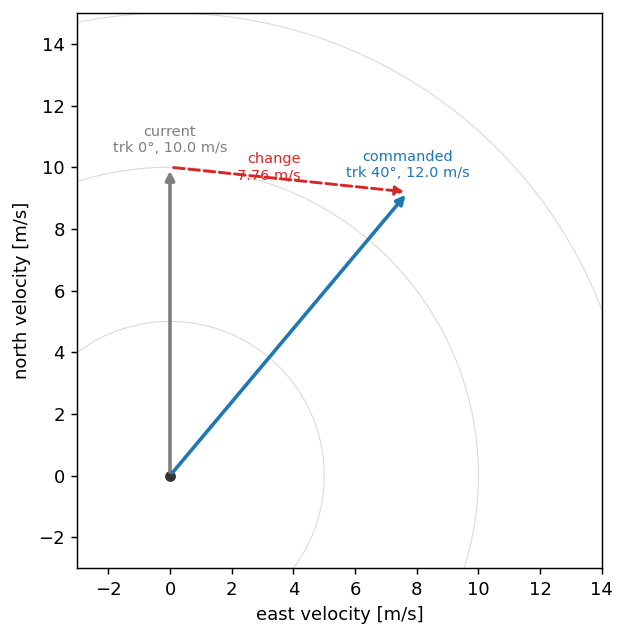

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.grid"] = False
BLUE, RED, GREY = "#1f77b4", "#d62728", "#7f7f7f"

current = MotionCommand.from_track_speed(0.0, 10.0)        # flying north at 10 m/s
avoid = MotionCommand.from_track_speed(40.0, 12.0)         # turn right and speed up
delta = (avoid.v_east - current.v_east, avoid.v_north - current.v_north)

fig, ax = plt.subplots(figsize=(5.4, 5.0))
for cmd, colour, label in ((current, GREY, "current"), (avoid, BLUE, "commanded")):
    ax.annotate("", (cmd.v_east, cmd.v_north), (0, 0),
                arrowprops=dict(arrowstyle="-|>", color=colour, lw=2.0))
    ax.text(cmd.v_east, cmd.v_north + 0.4,
            f"{label}\ntrk {cmd.trk:.0f}°, {cmd.gs:.1f} m/s", color=colour, fontsize=8,
            ha="center", va="bottom")
ax.annotate("", (avoid.v_east, avoid.v_north), (current.v_east, current.v_north),
            arrowprops=dict(arrowstyle="-|>", color=RED, lw=1.6, ls="--"))
ax.text(avoid.v_east * 0.55, (current.v_north + avoid.v_north) / 2,
        f"change\n{np.hypot(*delta):.2f} m/s", color=RED, fontsize=8, ha="right")

for radius in (5.0, 10.0, 15.0):
    theta = np.linspace(0, 2 * np.pi, 200)
    ax.plot(radius * np.cos(theta), radius * np.sin(theta), lw=0.6, color="0.85", zorder=0)
ax.plot(0, 0, marker="o", ms=5, color="0.2")
ax.set_aspect("equal")
ax.set_xlim(-3, 14)
ax.set_ylim(-3, 15)
ax.set_xlabel("east velocity [m/s]")
ax.set_ylabel("north velocity [m/s]")
fig.tight_layout()

## Do it yourself

1. Build the same command with `from_track_speed(225.0, 8.0)` and with `from_velocity`. Check that
   `gs` and `trk` agree on both.
2. Give a `Multirotor` a command with only `target_yaw` set. Read the error, and name the channel it
   asks for.
3. Project a 30 m/s velocity command for `SMALL_FIXEDWING`. Check the result against `v_max`.

## Check

1. Why is `None` different from `0.0`? Give an example with `target_yaw`.
2. Which channels does a `Multirotor` read? Which does a `FixedWing` read?
3. A resolver returns `target_velocity`. What has to happen before a fixed-wing can fly it?

## Next

`L1.5 — The multirotor kinematics`. You can write a command. Next you give it to a model and move
an aircraft.